Relação estado reuso: 
{2: 5, 3: 4, 4: 3, 5: 2, 6: 1}


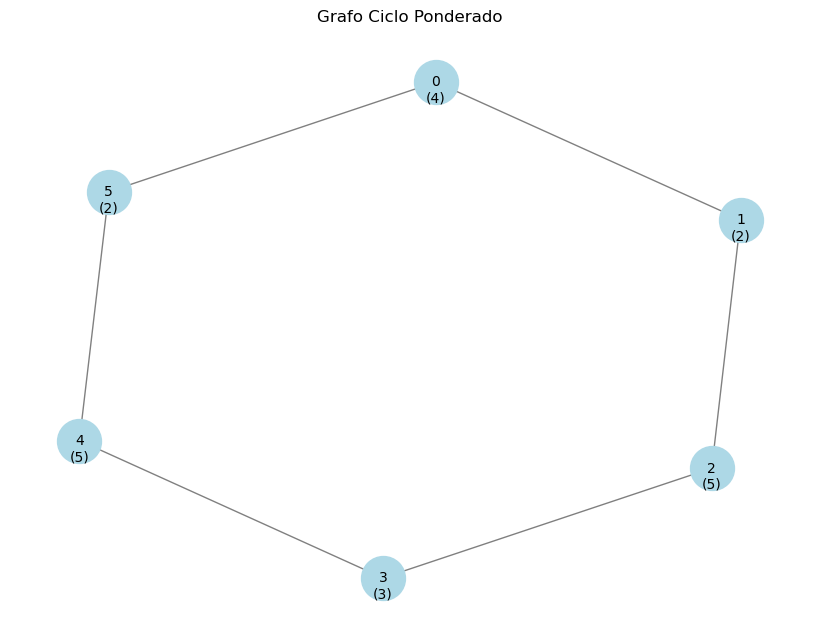

Iniciou às 2025-04-08 22:06:13.977
[0.0010 s] Tamanho do memo: 64 bytes
[0.0010 s] Tamanho do memo: 64 bytes
[0.0010 s] Tamanho do memo: 504 bytes
[0.0010 s] Tamanho do memo: 504 bytes
[0.0010 s] Tamanho do memo: 504 bytes
[0.0010 s] Tamanho do memo: 736 bytes
[0.0010 s] Tamanho do memo: 736 bytes
[0.0010 s] Tamanho do memo: 952 bytes
[0.0010 s] Tamanho do memo: 952 bytes
[0.0010 s] Tamanho do memo: 952 bytes
[0.0010 s] Tamanho do memo: 952 bytes
[0.0020 s] Tamanho do memo: 1168 bytes
[0.0020 s] Tamanho do memo: 1168 bytes
[0.0020 s] Tamanho do memo: 1368 bytes
[0.0020 s] Tamanho do memo: 1368 bytes
[0.0020 s] Tamanho do memo: 1680 bytes
[0.0020 s] Tamanho do memo: 1680 bytes
[0.0020 s] Tamanho do memo: 1680 bytes
[0.0020 s] Tamanho do memo: 1680 bytes
[0.0020 s] Tamanho do memo: 1680 bytes
[0.0020 s] Tamanho do memo: 1976 bytes
[0.0030 s] Tamanho do memo: 1976 bytes
[0.0030 s] Tamanho do memo: 2224 bytes
[0.0030 s] Tamanho do memo: 2224 bytes
[0.0030 s] Tamanho do memo: 2424 bytes
[0.

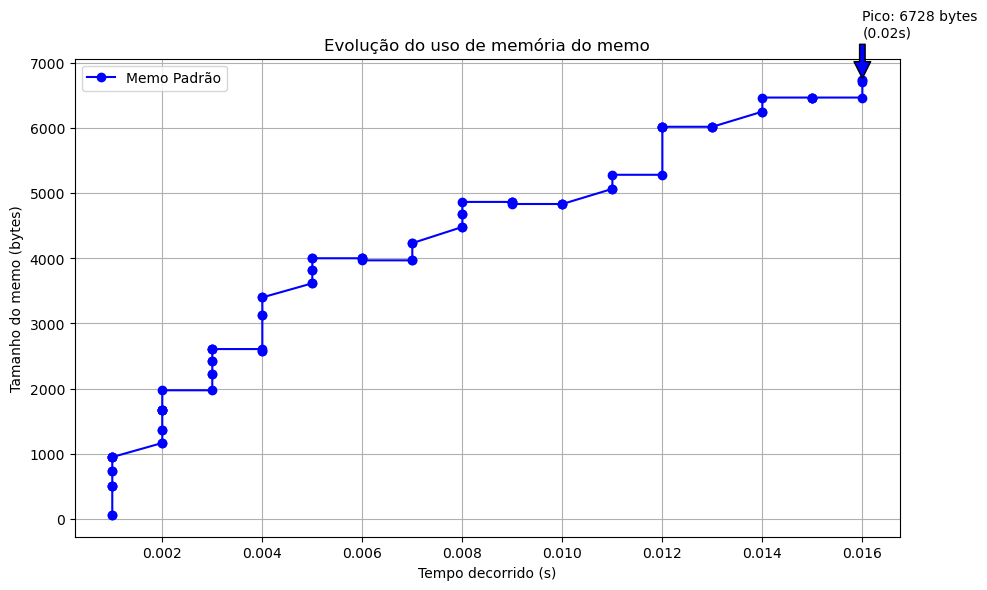

melhor escolha:  2
[1, 4]
[2, 1, 4]
12

 ======== Bicoloração em Caminho: ==========

Sequencia vencedora da Ana: [2, 1, 4] : Peso = 12 
Tempo de execução: 0.001001119613647461 segundos


In [1]:
from geracao_grafos import *
from problemasPolinomiais.gulosoBicoloridoCiclo import *
from problemasPolinomiais.gulosoCompleto import *
from funcoesDP import *
from valG import *
from pympler import asizeof
#!pip install pympler

from otimizacoesPD.caminho_otimizado_pd import *
import gc
import sys


def mainSemDp(grafo, pesos):
    
    inicio_tempo = time.time()
    melhor_valor, arvore_decisao, melhor_caminho = valor(grafo, pesos)
    fim_tempo = time.time()
    print("Sem Programação Dinâmica:")
    print("Melhor caminho:", melhor_caminho)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    calcular_ganhos(melhor_caminho, pesos)
    imprimirArvoreDecisao(arvore_decisao,False)


def mainDP(grafo, pesos):
    inicio_tempo = time.time()
    memo = {}
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # Mantém milissegundos
  # Captura o instante de reutilização
    print(f"Iniciou às {timestamp}")
    melhor_valor_dp, melhor_caminho_dp = valor_dp(grafo, pesos, memo,inicio_tempo)
    fim_tempo = time.time()
    print("\nCom Programação Dinâmica :")
    print("Melhor caminho:", melhor_caminho_dp)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    quantidade_estados = contar_estados(grafo)
    print("Quantidade de estados  a serem gerados:", quantidade_estados)
    print("Número de entradas na tabela dinâmica:", len(memo))
    print("Tamanho total do memo (real):", asizeof.asizeof(memo), "bytes")
    print("Número de reusos:", len(contagem_reuso_dp))
    print("Número de estados distintos usados: ",len(estados_reusados))
    calcular_ganhos(melhor_caminho_dp, pesos)
    #imprime_estados_reusados()
    #imprime_estados_nao_reutilizados(memo)
    return logs_memo
    #imprime_tabela_dp(memo)
    #imprimirArvoreDecisao(arvore_decisao_dp)

def mainDP_Bipartido(grafo, pesos,m,n):
    inicio_tempo = time.time()
    memo = {}
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # Mantém milissegundos
  # Captura o instante de reutilização
    print(f"Iniciou às {timestamp}")
    melhor_valor_dp, melhor_caminho_dp = valor_dp_bipartido(grafo, pesos, memo,m,n,inicio_tempo)
    fim_tempo = time.time()
    print("\nCom Programação Dinâmica Kmn Otimizado:")
    print("Melhor caminho:", melhor_caminho_dp)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    quantidade_estados = contar_estados(grafo)
    print("Quantidade de estados  a serem gerados:", quantidade_estados)
    print("Número de entradas na tabela dinâmica:", len(memo))
    print("Tamanho total do memo (real):", asizeof.asizeof(memo), "bytes")
    print("Número de reusos:", len(contagem_reuso_dp))
    print("Número de estados distintos usados: ",len(estados_reusados))
    calcular_ganhos(melhor_caminho_dp, pesos)
    #imprime_estados_reusados()
    #imprime_estados_nao_reutilizados(memo)
    return logs_memoKmn
    #imprime_tabela_dp(memo)
    #imprimirArvoreDecisao(arvore_decisao_dp)


def main():
    gc.collect()  # Força a coleta de lixo
    m, n = 4,4
    altura = 4
    gerar_reuso_estados(m, n)
    grafo, pesos = gerar_grafo_ciclo(6)      # Gera um ciclo de 5 nós
    #grafo, pesos = gerar_grafo_completo(13)   # Gera um grafo completo de 6 nós
    #grafo, pesos = gerar_grafo_caminho(6)    # Gera um caminho de 4 nós
    #grafo, pesos, conjunto_x, conjunto_y = criar_grafo_bipartido(m, n)
    #grafo, pesos, conjunto_x, conjunto_y = criar_grafo_bipartido_completo(m, n)
    #grafo, pesos = grafoSimples()
    #grafo, pesos = arvoreCompleta(altura)
    

    mainDP( grafo, pesos)
    contagem_reuso_dp = []

    print("==================================================================================================")
    print("==================================================================================================")
    #mainDP_Bipartido(grafo,pesos,m,n)
    print("==================================================================================================")
    print("==================================================================================================")
    plotar_evolucao_memo(logs_memo,logs_memoKmn)

    #main_caminho_otimiziado_pd(grafo,pesos)

    #mainSemDp( grafo, pesos)

    #mainBicoloracaoCaminho( grafo, pesos)
    mainGulosoCompleto(grafo,pesos)
    #mainGulosoBicoloridoCiclo(grafo,pesos)

if __name__ == "__main__":
    main()